# M16: Business Insights & Recommendations
In this final notebook, we combine the model's predictions with business segmentation to extract actionable insights. We'll group the customer base by the top features identified in M15 (Tenure, Contract, Monthly Charges) and compute the predicted churn rate for each segment.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))
from src.data import load_raw_data
from src.cleaning import clean_data
from src.features import build_features
from src.split import split_data

# Load data and model
df_raw = clean_data(load_raw_data("../data/raw"))
df_features = build_features(df_raw, scale=False)
_, X_test, _, y_test = split_data(df_features)

model = joblib.load("../models/best_churn_model.pkl")

# We want the original test data for interpretation (unencoded where possible, but we'll use X_test for predictions and join back to df_raw)
y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else model.predict(X_test)

# Join predictions back to original test indices
results = df_raw.loc[X_test.index].copy()
results['Predicted_Churn_Prob'] = y_prob
results['Actual_Churn'] = y_test


## 1. Segmenting by Contract Type
Contract type is typically a major driver. Let's look at the average predicted churn probability per contract type.

         Contract  Predicted_Churn_Prob  Actual_Churn
0  Month-to-month              0.551786      0.425614
1        One year              0.135086      0.120000
2        Two year              0.050545      0.026786


C:\Users\Bardan Khatiwada\AppData\Local\Temp\ipykernel_25408\767916455.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=contract_summary, x='Contract', y='Predicted_Churn_Prob', palette='Blues_d')


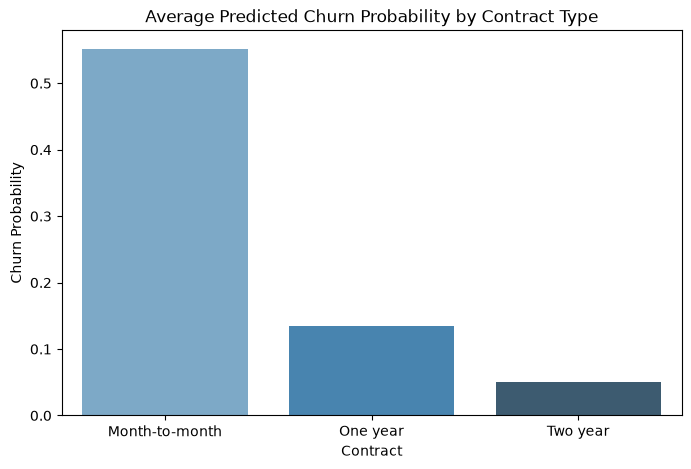

In [2]:
contract_summary = results.groupby('Contract')[['Predicted_Churn_Prob', 'Actual_Churn']].mean().reset_index()
print(contract_summary)

plt.figure(figsize=(8, 5))
sns.barplot(data=contract_summary, x='Contract', y='Predicted_Churn_Prob', palette='Blues_d')
plt.title("Average Predicted Churn Probability by Contract Type")
plt.ylabel("Churn Probability")
plt.show()


## 2. Segmenting by Tenure Group
New customers usually have a higher risk of leaving.

C:\Users\Bardan Khatiwada\AppData\Local\Temp\ipykernel_25408\4021467471.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tenure_summary, x='Tenure_Bin', y='Predicted_Churn_Prob', palette='Reds_d')


  Tenure_Bin  Predicted_Churn_Prob  Actual_Churn
0      0-1yr              0.568792      0.482063
1     1-2yrs              0.402793      0.291262
2     2-4yrs              0.280562      0.210526
3     4-5yrs              0.199007      0.109195
4      5+yrs              0.098614      0.057971


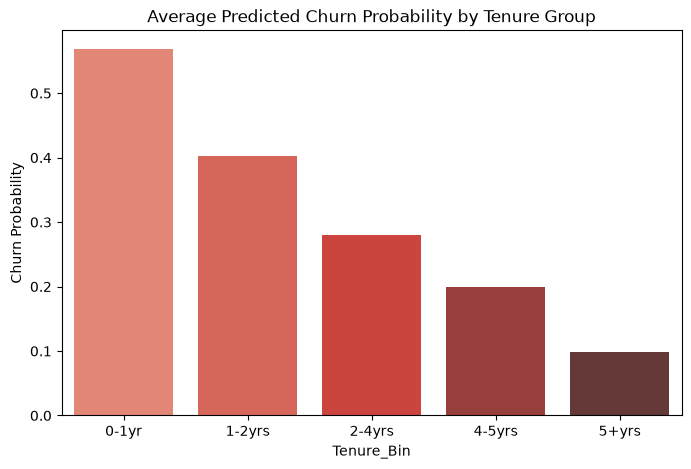

In [3]:
# Create tenure bins for original data just for this analysis
results['Tenure_Bin'] = pd.cut(results['tenure'], bins=[0, 12, 24, 48, 60, 100], labels=['0-1yr', '1-2yrs', '2-4yrs', '4-5yrs', '5+yrs'])

tenure_summary = results.groupby('Tenure_Bin', observed=False)[['Predicted_Churn_Prob', 'Actual_Churn']].mean().reset_index()
print(tenure_summary)

plt.figure(figsize=(8, 5))
sns.barplot(data=tenure_summary, x='Tenure_Bin', y='Predicted_Churn_Prob', palette='Reds_d')
plt.title("Average Predicted Churn Probability by Tenure Group")
plt.ylabel("Churn Probability")
plt.show()


## 3. High-Risk Customer Profile
Let's filter out the highest risk customers (Prob > 0.8) and summarize their profile.

In [4]:
high_risk = results[results['Predicted_Churn_Prob'] > 0.8]
print(f"Total High Risk Customers in Test Set: {len(high_risk)} ({len(high_risk)/len(results)*100:.1f}%)")
print("\nTop Contract Types in High Risk:")
print(high_risk['Contract'].value_counts(normalize=True).round(3))
print("\nTop Internet Services in High Risk:")
print(high_risk['InternetService'].value_counts(normalize=True).round(3))
print("\nAverage Monthly Charges (High Risk vs Overall):")
print(f"High Risk: ${high_risk['MonthlyCharges'].mean():.2f}")
print(f"Overall: ${results['MonthlyCharges'].mean():.2f}")


Total High Risk Customers in Test Set: 158 (11.2%)

Top Contract Types in High Risk:
Contract
Month-to-month    1.0
Name: proportion, dtype: float64

Top Internet Services in High Risk:
InternetService
Fiber optic    0.899
DSL            0.101
Name: proportion, dtype: float64

Average Monthly Charges (High Risk vs Overall):
High Risk: $78.42
Overall: $64.09


## Recommendations
1. **Incentivize Long-Term Contracts**: The vast majority of high-risk customers are on month-to-month contracts. Offer discounts for 1-year commitments.
2. **First-Year Retention Program**: Customers in their first year (`0-1yr`) have the highest churn probability. Implement a proactive check-in at month 3 and month 6.
3. **Fiber Optic Review**: High risk customers frequently use Fiber Optic internet. Investigate if there are pricing or reliability issues with this specific service tier.